# Random Forest for CMAPSS FD001

This notebook trains a random forest model to predict remaining useful life (RUL) for the CMAPSS jet engine dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
DATASET = "FD001"
RANDOM_STATE = 42
MAX_RUL = 125  # Set to None if you do not want to cap the target.

index_cols = ["engine_id", "cycle"]
setting_cols = [f"setting_{i}" for i in range(1, 4)]
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
columns = index_cols + setting_cols + sensor_cols

train_path = f"CMAPSSData/train_{DATASET}.txt"
test_path = f"CMAPSSData/test_{DATASET}.txt"
rul_path = f"CMAPSSData/RUL_{DATASET}.txt"

train_df = pd.read_csv(train_path, sep=r"\s+", header=None)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None)
test_rul = pd.read_csv(rul_path, sep=r"\s+", header=None)

train_df.columns = columns
test_df.columns = columns
test_rul.columns = ["true_rul"]
test_rul["engine_id"] = np.arange(1, len(test_rul) + 1)

train_df = train_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
test_df = test_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)

max_cycle_by_engine = train_df.groupby("engine_id")["cycle"].transform("max")
train_df["RUL"] = max_cycle_by_engine - train_df["cycle"]

if MAX_RUL is not None:
    train_df["RUL"] = train_df["RUL"].clip(upper=MAX_RUL)

candidate_features = [c for c in train_df.columns if c not in ["engine_id", "RUL"]]

print(f"Training rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Number of engines in training set: {train_df['engine_id'].nunique()}")
print(f"Number of engines in test set: {test_df['engine_id'].nunique()}")
print(f"Candidate features before filtering ({len(candidate_features)}): {candidate_features}")

Training rows: 20,631
Test rows: 13,096
Number of engines in training set: 100
Number of engines in test set: 100
Candidate features before filtering (25): ['cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [3]:
train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


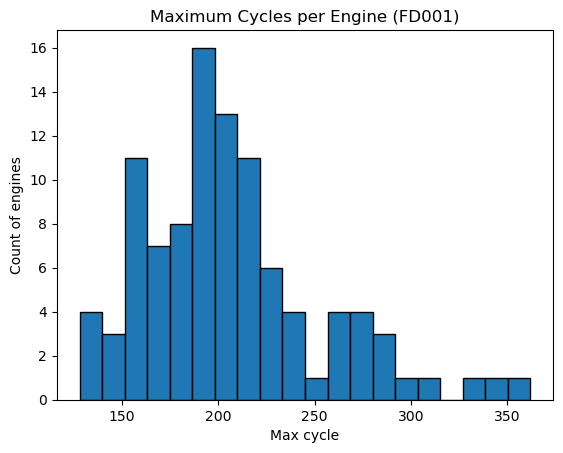

In [4]:
cycles = train_df.groupby("engine_id")["cycle"].max()
cycles.plot(kind="hist", bins=20, edgecolor="black")
plt.title(f"Maximum Cycles per Engine ({DATASET})")
plt.xlabel("Max cycle")
plt.ylabel("Count of engines")
plt.show()

In [5]:
# Split by engine_id so the same engine does not appear in both train and validation data.
engine_ids = train_df["engine_id"].unique()
train_engine_ids, val_engine_ids = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_split = train_df[train_df["engine_id"].isin(train_engine_ids)].copy()
val_split = train_df[train_df["engine_id"].isin(val_engine_ids)].copy()

# Learn preprocessing choices from the training split only.
constant_features = [c for c in candidate_features if train_split[c].nunique() <= 1]
feature_cols = [c for c in candidate_features if c not in constant_features]

print(f"Training engines: {len(train_engine_ids)}")
print(f"Validation engines: {len(val_engine_ids)}")
print(f"Dropped constant features: {constant_features}")
print(f"Features used ({len(feature_cols)}): {feature_cols}")

X_train = train_split[feature_cols]
y_train = train_split["RUL"]
X_val = val_split[feature_cols]
y_val = val_split["RUL"]

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
val_pred = rf_model.predict(X_val)

val_rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))
val_mae = float(mean_absolute_error(y_val, val_pred))
val_r2 = float(r2_score(y_val, val_pred))

print(f"Validation RMSE: {val_rmse:.3f}")
print(f"Validation MAE: {val_mae:.3f}")
print(f"Validation R^2: {val_r2:.3f}")

Training engines: 80
Validation engines: 20
Dropped constant features: ['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Features used (18): ['cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Validation RMSE: 15.952
Validation MAE: 10.795
Validation R^2: 0.854


In [6]:
# For the official test set, the RUL label corresponds to the final observed cycle for each engine.
test_last = test_df.groupby("engine_id").tail(1).copy()
test_last = test_last.merge(test_rul, on="engine_id", how="left")

if MAX_RUL is not None:
    test_last["true_rul"] = test_last["true_rul"].clip(upper=MAX_RUL)

test_pred = rf_model.predict(test_last[feature_cols])
test_rmse = float(np.sqrt(mean_squared_error(test_last["true_rul"], test_pred)))
test_mae = float(mean_absolute_error(test_last["true_rul"], test_pred))
test_r2 = float(r2_score(test_last["true_rul"], test_pred))

results_df = pd.DataFrame({
    "engine_id": test_last["engine_id"],
    "actual_rul": test_last["true_rul"],
    "predicted_rul": np.round(test_pred, 2),
    "error": np.round(test_pred - test_last["true_rul"], 2)
}).sort_values("engine_id")

print(f"Test RMSE: {test_rmse:.3f}")
print(f"Test MAE: {test_mae:.3f}")
print(f"Test R^2: {test_r2:.3f}")

results_df.head(10)

Test RMSE: 16.893
Test MAE: 12.547
Test R^2: 0.822


,engine_id,actual_rul,predicted_rul,error
0,1,112,123.65,11.65
1,2,98,123.61,25.61
2,3,69,59.85,-9.15
3,4,82,77.74,-4.26
4,5,91,94.97,3.97
5,6,93,85.35,-7.65
6,7,91,106.59,15.59
7,8,95,65.86,-29.14
8,9,111,117.93,6.93
9,10,96,109.23,13.23


sensor_11    0.479745
cycle        0.270605
sensor_9     0.054579
sensor_4     0.047013
sensor_12    0.022285
sensor_7     0.018569
sensor_14    0.017064
sensor_15    0.016568
sensor_21    0.011456
sensor_2     0.010692
dtype: float64

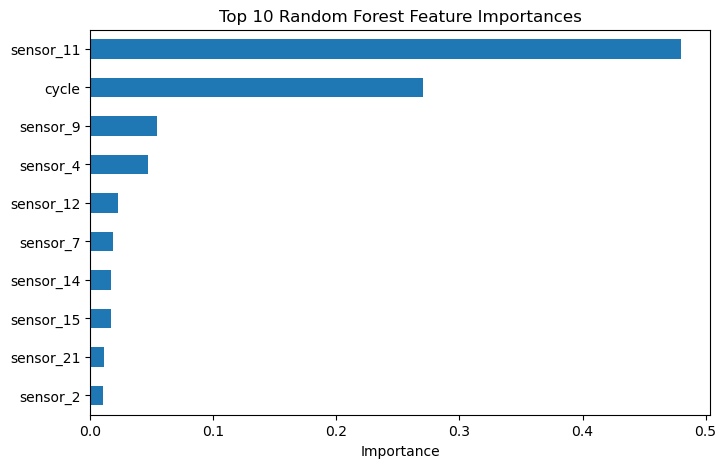

In [7]:
feature_importance = (
    pd.Series(rf_model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)

display(feature_importance.head(10))

feature_importance.head(10).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

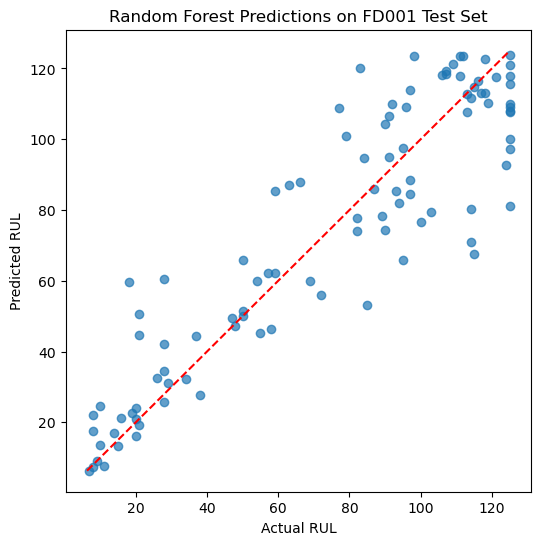

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(test_last["true_rul"], test_pred, alpha=0.7)
min_val = min(test_last["true_rul"].min(), test_pred.min())
max_val = max(test_last["true_rul"].max(), test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title(f"Random Forest Predictions on {DATASET} Test Set")
plt.show()

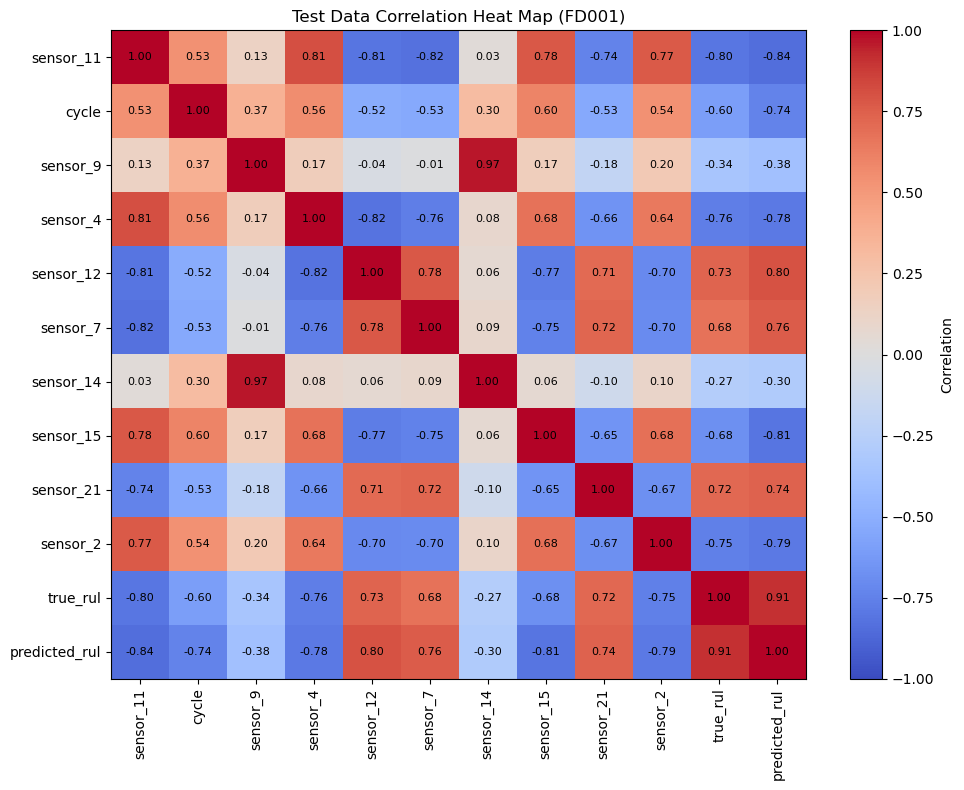

In [9]:
# Heat map for the test data using the current model's top features.
top_heatmap_features = feature_importance.head(10).index.tolist()
heatmap_df = test_last[top_heatmap_features].copy()
heatmap_df["true_rul"] = test_last["true_rul"].values
heatmap_df["predicted_rul"] = test_pred

corr_matrix = heatmap_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title(f"Test Data Correlation Heat Map ({DATASET})")

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color="black")

plt.tight_layout()
plt.show()

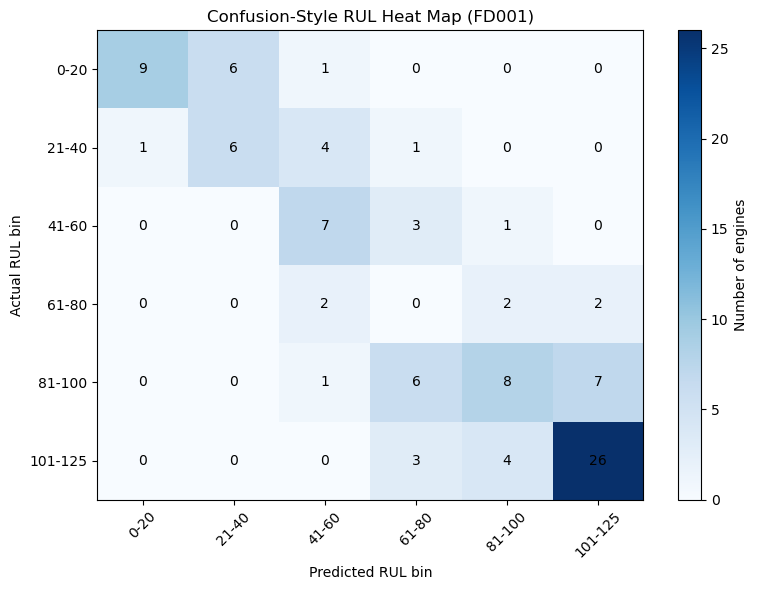

predicted_bin,0-20,21-40,41-60,61-80,81-100,101-125
actual_bin,,,,,,
0-20,9,6,1,0,0,0
21-40,1,6,4,1,0,0
41-60,0,0,7,3,1,0
61-80,0,0,2,0,2,2
81-100,0,0,1,6,8,7
101-125,0,0,0,3,4,26


In [10]:
# Confusion-style heat map for the regression model by binning RUL into ranges.
bin_edges = [0, 20, 40, 60, 80, 100, 125]
bin_labels = ["0-20", "21-40", "41-60", "61-80", "81-100", "101-125"]

confusion_df = results_df.copy()
confusion_df["actual_bin"] = pd.cut(
    confusion_df["actual_rul"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)
confusion_df["predicted_bin"] = pd.cut(
    confusion_df["predicted_rul"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

confusion_matrix = pd.crosstab(
    confusion_df["actual_bin"],
    confusion_df["predicted_bin"],
    dropna=False
)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, cmap="Blues", aspect="auto")
plt.colorbar(label="Number of engines")
plt.xticks(range(len(confusion_matrix.columns)), confusion_matrix.columns, rotation=45)
plt.yticks(range(len(confusion_matrix.index)), confusion_matrix.index)
plt.xlabel("Predicted RUL bin")
plt.ylabel("Actual RUL bin")
plt.title(f"Confusion-Style RUL Heat Map ({DATASET})")

for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        plt.text(j, i, confusion_matrix.iloc[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

confusion_matrix